# 02e — Visualization: Stage A/B Walk-Forward CV Results

Replaces `legacy_pre_revision/06_visualization.ipynb`, which read `phase1_screening_results.csv` /
`phase2_group_results.csv` from the superseded single-split pipeline. This reads the new
walk-forward CV outputs: `stage_a_fold_results.csv` / `stage_a_summary.csv` (Stage A,
default hyperparameters) and `nested_cv_outer_fold_results.csv` (Stage B, tuned).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_stage_a = pd.read_csv("stage_a_fold_results.csv")
df_stage_a_summary = pd.read_csv("stage_a_summary.csv")
df_outer = pd.read_csv("nested_cv_outer_fold_results.csv")
winning_config = joblib.load("saved_models/winning_config.joblib")

print(f"Stage A: {len(df_stage_a_summary)} combos, {len(df_stage_a)} fold-results")
print(f"Stage B: {len(df_outer)} outer folds for the winning config")
print(f"Winning config: {winning_config['model']} | {winning_config['covariates']} | "
      f"W{winning_config['window']}_H{winning_config['horizon']}")

Stage A: 504 combos, 2520 fold-results
Stage B: 5 outer folds for the winning config
Winning config: ExtraTrees | Screening1 | W120_H1


## 1. Heatmap: mean CV MAPE per Model x Covariate scenario (best window/horizon each)

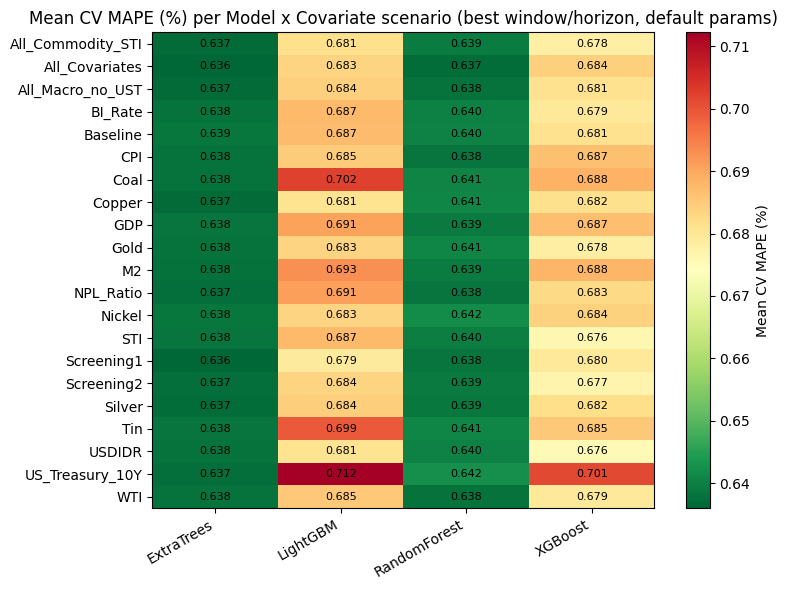

Saved: plot_stage_a_heatmap_mape.png


In [2]:
best_per_combo = (
    df_stage_a_summary.loc[df_stage_a_summary.groupby(["Model", "Covariates"])["mape_mean"].idxmin()]
)
pivot = best_per_combo.pivot(index="Covariates", columns="Model", values="mape_mean")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Mean CV MAPE (%) per Model x Covariate scenario (best window/horizon, default params)")
fig.colorbar(im, ax=ax, label="Mean CV MAPE (%)")
plt.tight_layout()
fig.savefig("plot_stage_a_heatmap_mape.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_stage_a_heatmap_mape.png")

## 2. Window comparison: W20 vs W120, mean MAPE across all scenarios per model

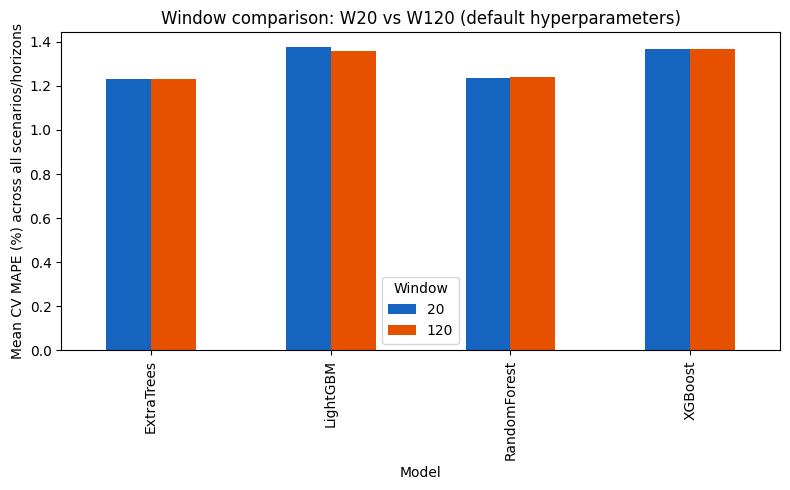

Saved: plot_stage_a_window_comparison.png


In [3]:
window_cmp = df_stage_a_summary.groupby(["Model", "Window"])["mape_mean"].mean().unstack()
ax = window_cmp.plot(kind="bar", figsize=(8, 5), color=["#1565C0", "#E65100"])
ax.set_ylabel("Mean CV MAPE (%) across all scenarios/horizons")
ax.set_title("Window comparison: W20 vs W120 (default hyperparameters)")
ax.legend(title="Window")
plt.tight_layout()
plt.savefig("plot_stage_a_window_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_stage_a_window_comparison.png")

## 3. Directional accuracy by model (Stage A, default params)

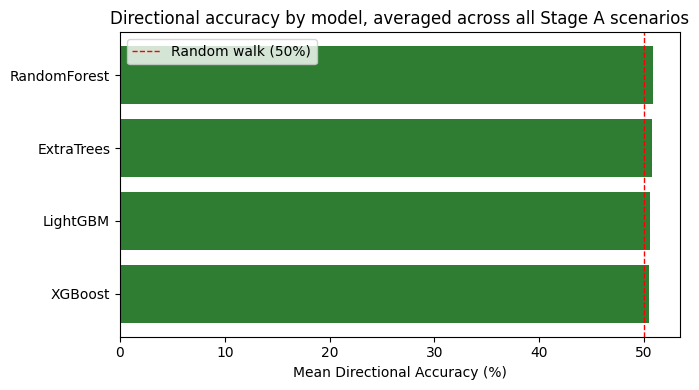

Saved: plot_stage_a_directional_accuracy.png


In [4]:
da_cmp = df_stage_a_summary.groupby("Model")["da_mean"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(da_cmp.index, da_cmp.values, color="#2E7D32")
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="Random walk (50%)")
ax.set_xlabel("Mean Directional Accuracy (%)")
ax.set_title("Directional accuracy by model, averaged across all Stage A scenarios")
ax.legend()
plt.tight_layout()
plt.savefig("plot_stage_a_directional_accuracy.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_stage_a_directional_accuracy.png")

## 4. Winning config: default vs. tuned MAPE per fold, with regime-shift flags

Boxplot-style view of fold-to-fold variance -- makes it visible when the mean default-vs-tuned
improvement is being pulled around by one or two regime-shift folds rather than being uniform.


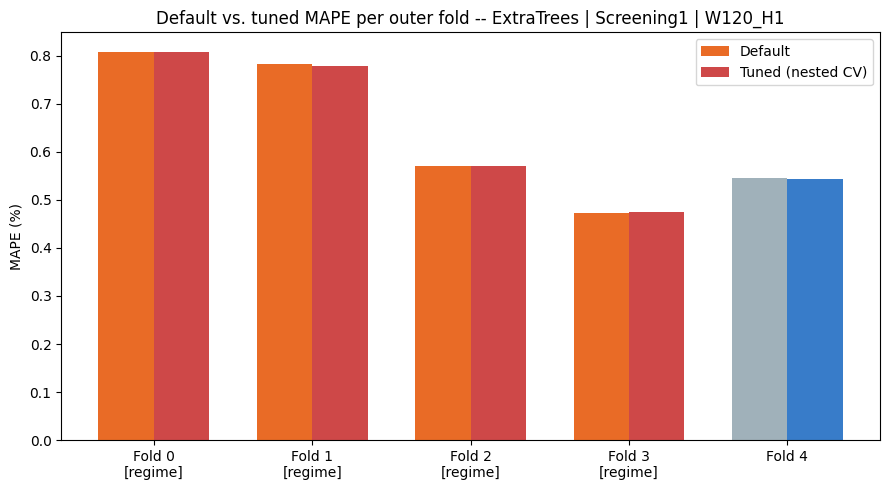

Saved: plot_nested_cv_default_vs_tuned.png
Mean improvement (all folds): 0.07%
Mean improvement (regime-flagged folds only): 0.00% (n=4)


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_outer))
width = 0.35
colors_default = ["#E65100" if pd.notna(r) else "#90A4AE" for r in df_outer["regime_flags"]]
colors_tuned = ["#C62828" if pd.notna(r) else "#1565C0" for r in df_outer["regime_flags"]]

ax.bar(x - width/2, df_outer["default_mape"], width, label="Default", color=colors_default, alpha=0.85)
ax.bar(x + width/2, df_outer["tuned_mape"], width, label="Tuned (nested CV)", color=colors_tuned, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {f}" + ("\n[regime]" if pd.notna(r) else "")
                     for f, r in zip(df_outer["Fold"], df_outer["regime_flags"])])
ax.set_ylabel("MAPE (%)")
ax.set_title(f"Default vs. tuned MAPE per outer fold -- {winning_config['model']} | "
             f"{winning_config['covariates']} | W{winning_config['window']}_H{winning_config['horizon']}")
ax.legend()
plt.tight_layout()
plt.savefig("plot_nested_cv_default_vs_tuned.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_nested_cv_default_vs_tuned.png")

mean_imp = ((df_outer["default_mape"] - df_outer["tuned_mape"]) / df_outer["default_mape"] * 100).mean()
flagged_imp = ((df_outer[df_outer["regime_flags"].notna()]["default_mape"] -
                df_outer[df_outer["regime_flags"].notna()]["tuned_mape"]) /
               df_outer[df_outer["regime_flags"].notna()]["default_mape"] * 100)
print(f"Mean improvement (all folds): {mean_imp:.2f}%")
if len(flagged_imp):
    print(f"Mean improvement (regime-flagged folds only): {flagged_imp.mean():.2f}% (n={len(flagged_imp)})")

## 5. Summary table

In [6]:
print("Top 10 Stage A configurations (default params, mean CV MAPE):")
display(df_stage_a_summary.sort_values("mape_mean").head(10)
        [["Model", "Covariates", "Window", "Horizon", "mape_mean", "mape_std", "da_mean", "n_folds"]])

print("\nWinning configuration, default vs. tuned per fold:")
display(df_outer[["Fold", "test_start_date", "test_end_date", "default_mape", "tuned_mape", "regime_flags"]])

Top 10 Stage A configurations (default params, mean CV MAPE):


,Model,Covariates,Window,Horizon,mape_mean,mape_std,da_mean,n_folds
87,ExtraTrees,Screening1,120,1,0.63600,0.150138,52.424,5
6,ExtraTrees,All_Covariates,20,1,0.63624,0.150802,52.526,5
9,ExtraTrees,All_Covariates,120,1,0.63624,0.149967,52.318,5
3,ExtraTrees,All_Commodity_STI,120,1,0.63662,0.151693,51.444,5
42,ExtraTrees,Copper,20,1,0.63670,0.150321,52.784,5
15,ExtraTrees,All_Macro_no_UST,120,1,0.63676,0.150270,52.268,5
99,ExtraTrees,Silver,120,1,0.63702,0.150686,53.248,5
258,RandomForest,All_Covariates,20,1,0.63718,0.151115,53.556,5
93,ExtraTrees,Screening2,120,1,0.63726,0.151084,52.680,5
69,ExtraTrees,NPL_Ratio,120,1,0.63730,0.151541,51.650,5



Winning configuration, default vs. tuned per fold:


,Fold,test_start_date,test_end_date,default_mape,tuned_mape,regime_flags
0,0,2019-02-15,2020-08-12,0.8084,0.8077,covid_crash
1,1,2020-03-30,2021-09-23,0.7826,0.7788,covid_crash
2,2,2021-05-11,2022-11-04,0.5697,0.5711,rate_hike_cycle_2022
3,3,2022-06-22,2023-12-18,0.4734,0.4749,rate_hike_cycle_2022
4,4,2023-08-03,2025-01-28,0.5459,0.5441,NaN
